In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
print("Loading Dataset...")

X_train = np.load("/content/drive/MyDrive/AI_fer/X_train.npy")
X_test = np.load("/content/drive/MyDrive/AI_fer/X_test.npy")
y_train = np.load("/content/drive/MyDrive/AI_fer/y_train.npy")
y_test = np.load("/content/drive/MyDrive/AI_fer/y_test.npy")

print("\nDataset Information")
print("----------------------------")
print("Training data shape :", X_train.shape)
print("Testing data shape  :", X_test.shape)
print("Training labels     :", y_train.shape)
print("Testing labels      :", y_test.shape)
print("Pixel range         :", X_train.min(), "-", X_train.max())

Loading Dataset...

Dataset Information
----------------------------
Training data shape : (28709, 48, 48, 1)
Testing data shape  : (7178, 48, 48, 1)
Training labels     : (28709, 7)
Testing labels      : (7178, 7)
Pixel range         : 0.0 - 1.0


In [ ]:
# ============================================================
# Step 2: Create Training / Validation Split
# ============================================================

# Original training data is divided into:
# 80% Training
# 20% Validation
# Test data remains completely separate
# and is NOT used during training.

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)


print("\nAfter Train / Validation Split")
print("----------------------------")

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)


After Train / Validation Split
----------------------------
Training   : (22967, 48, 48, 1)
Validation : (5742, 48, 48, 1)
Testing    : (7178, 48, 48, 1)


In [ ]:
# ============================================================
# Step 3: Data Augmentation
# ============================================================

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

print("\nData augmentation created successfully.")


Data augmentation created successfully.


In [ ]:
# ============================================================
# Step 4: Define CNN Models
# Only hyperparameters are changed for comparison.
# ============================================================

def build_model(model_number):

    model = Sequential()

    # ========================================================
    # FIXED ARCHITECTURE
    # ========================================================

    model.add(Input(shape=(48,48,1)))

    # Block 1
    model.add(Conv2D(64,(3,3),activation="relu",                  # Connvulution layer 1
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(Conv2D(64,(3,3),activation="relu",
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2)))        # Pooling layer 1
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64,(3,3),activation="relu",                # Convulution layer 2
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(Conv2D(64,(3,3),activation="relu",
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2)))      # Pooling layer 2
    model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(128,(3,3),activation="relu",
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(Conv2D(128,(3,3),activation="relu",
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2)))
    model.add(Dropout(0.25))

    # Block 4
    model.add(Conv2D(256,(3,3),activation="relu",
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(Conv2D(256,(3,3),activation="relu",
                     padding="same",
                     kernel_initializer="he_normal"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2)))
    model.add(Dropout(0.50))

    # Fully Connected Layer
    model.add(Flatten())
    model.add(Dense(2048,
                    activation="relu",
                    kernel_initializer="he_normal"))
    model.add(Dropout(0.50))

    # Output Layer
    model.add(Dense(7,activation="softmax"))

    # ========================================================
    # HYPERPARAMETER SETTINGS
    # Architecture remains exactly the same.
    # ========================================================

    if model_number == 1:

        # Baseline hyperparameters
        learning_rate = 0.0001
        batch_size = 32

    elif model_number == 2:

        # Higher learning rate
        learning_rate = 0.0005
        batch_size = 32

    elif model_number == 3:

        # Lower learning rate
        learning_rate = 0.00005
        batch_size = 32

    elif model_number == 4:

        # Larger batch size
        learning_rate = 0.0001
        batch_size = 64

    elif model_number == 5:

        # Smaller batch size
        learning_rate = 0.0001
        batch_size = 16

    else:

        raise ValueError("Model number must be between 1 and 5.")

    # ========================================================
    # Compile Model
    # ========================================================

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, learning_rate, batch_size

In [ ]:
# ============================================================
# Step 5: Model Training Storage
# ============================================================

results = []
histories = {}
trained_models = {}


In [ ]:
# ============================================================
# Training Function
# ============================================================
def train_model(model_number):

    print("\n" + "="*60)
    print("TRAINING MODEL {}".format(model_number))
    print("="*60)

    model, learning_rate, batch_size = build_model(model_number)

    print("\nModel Architecture:")
    model.summary()

    earlystop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    start_time = time.time()

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=batch_size),
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=[earlystop],
        verbose=1
    )

    training_time = time.time() - start_time

    best_train_accuracy = max(history.history["accuracy"])
    best_train_loss = min(history.history["loss"])

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    trained_models[model_number] = model
    histories[model_number] = history

    results.append({
        "Model": "Model {}".format(model_number),
        "Parameters": model.count_params(),
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Training Accuracy": best_train_accuracy,
        "Validation Accuracy": best_val_accuracy,
        "Test Accuracy": test_accuracy,
        "Training Loss": best_train_loss,
        "Validation Loss": best_val_loss,
        "Test Loss": test_loss,
        "Training Time (sec)": training_time,
        "Epochs": len(history.history["loss"])
    })

    print("\nModel {} completed.".format(model_number))
    print("Best Training Accuracy:", best_train_accuracy)
    print("Best Validation Accuracy:", best_val_accuracy)
    print("Test Accuracy:", test_accuracy)
    print("Best Training Loss:", best_train_loss)
    print("Best Validation Loss:", best_val_loss)
    print("Test Loss:", test_loss)
    print("Parameters:", model.count_params())
    print("Training Time:", round(training_time, 2), "seconds")
    print("Epochs:", len(history.history["loss"]))

    return model, history

In [ ]:
# ============================================================
# Step 7: Train Model 1
# ============================================================

model1, history1 = train_model(1)


TRAINING MODEL 1

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             

 Total params: 3,333,703 (12.72 MB)

 Trainable params: 3,332,679 (12.71 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.1965 - loss: 3.4981 - val_accuracy: 0.2658 - val_loss: 1.8760
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.2133 - loss: 2.0122 - val_accuracy: 0.2706 - val_loss: 1.9624
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.2274 - loss: 1.8569 - val_accuracy: 0.2724 - val_loss: 2.1919
Epoch 4/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.2391 - loss: 1.8138 - val_accuracy: 0.2867 - val_loss: 2.3023
Epoch 5/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.2558 - loss: 1.7830 - val_accuracy: 0.2867 - val_loss: 2.1501
Epoch 6/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.2740 - loss: 1.7498 - val_accuracy: 0.2907 - val_loss: 2.1742
Epoch 7/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3017 - loss: 1.7012 - val_accuracy: 0.2172 - val_loss: 2.8067
Epoch 8/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3263 - loss: 1

In [ ]:
# ============================================================
# Step 7: Train Model 2
# ============================================================

model2, history2 = train_model(2)


TRAINING MODEL 2

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2048)           │             

 Total params: 3,333,703 (12.72 MB)

 Trainable params: 3,332,679 (12.71 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.2160 - loss: 2.3988 - val_accuracy: 0.2036 - val_loss: 4.0220
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2646 - loss: 1.7768 - val_accuracy: 0.2602 - val_loss: 3.3823
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3094 - loss: 1.7021 - val_accuracy: 0.3595 - val_loss: 2.4043
Epoch 4/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3528 - loss: 1.6290 - val_accuracy: 0.2508 - val_loss: 4.7667
Epoch 5/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3891 - loss: 1.5611 - val_accuracy: 0.4073 - val_loss: 1.6464
Epoch 6/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4130 - loss: 1.5022 - val_accuracy: 0.4556 - val_loss: 1.4056
Epoch 7/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.4411 - loss: 1.4500 - val_accuracy: 0.4060 - val_loss: 1.5464
Epoch 8/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4545 - loss: 1

In [ ]:
# ============================================================
# Step 8: Train Model 3
# ============================================================

model3, history3 = train_model(3)


TRAINING MODEL 3

Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 2048)           │             

 Total params: 3,333,703 (12.72 MB)

 Trainable params: 3,332,679 (12.71 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.1917 - loss: 4.2575 - val_accuracy: 0.2537 - val_loss: 1.8486
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.2002 - loss: 2.4953 - val_accuracy: 0.2734 - val_loss: 1.8515
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2120 - loss: 2.0733 - val_accuracy: 0.2752 - val_loss: 1.9063
Epoch 4/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2161 - loss: 1.9234 - val_accuracy: 0.2719 - val_loss: 2.0336
Epoch 5/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2299 - loss: 1.8521 - val_accuracy: 0.2816 - val_loss: 1.9593
Epoch 6/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.2385 - loss: 1.8299 - val_accuracy: 0.2847 - val_loss: 2.0723
Epoch 7/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2495 - loss: 1.8039 - val_accuracy: 0.2818 - val_loss: 2.1652
Epoch 8/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2571 - loss: 1

In [ ]:
# ============================================================
# Step 9: Train Model 4
# ============================================================

model4, history4 = train_model(4)


TRAINING MODEL 4

Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 2048)           │             

 Total params: 3,333,703 (12.72 MB)

 Trainable params: 3,332,679 (12.71 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.1929 - loss: 3.8669 - val_accuracy: 0.2504 - val_loss: 1.9746
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.2064 - loss: 2.2652 - val_accuracy: 0.2783 - val_loss: 1.9197
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2197 - loss: 1.9507 - val_accuracy: 0.2874 - val_loss: 1.9020
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2312 - loss: 1.8603 - val_accuracy: 0.2832 - val_loss: 1.9600
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.2417 - loss: 1.8196 - val_accuracy: 0.2874 - val_loss: 2.3523
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2504 - loss: 1.7939 - val_accuracy: 0.2976 - val_loss: 2.0989
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2649 - loss: 1.7749 - val_accuracy: 0.3076 - val_loss: 2.2912
Epoch 8/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2766 - loss: 1

In [ ]:
# ============================================================
# Train model 5
# ============================================================
model5, history5 = train_model(5)


TRAINING MODEL 5

Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 2048)           │             

 Total params: 3,333,703 (12.72 MB)

 Trainable params: 3,332,679 (12.71 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.1947 - loss: 3.0746 - val_accuracy: 0.2799 - val_loss: 1.9019
Epoch 2/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.2153 - loss: 1.9022 - val_accuracy: 0.2635 - val_loss: 2.1701
Epoch 3/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.2415 - loss: 1.8175 - val_accuracy: 0.2846 - val_loss: 1.9525
Epoch 4/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.2660 - loss: 1.7713 - val_accuracy: 0.2846 - val_loss: 2.1181
Epoch 5/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.2995 - loss: 1.7168 - val_accuracy: 0.3046 - val_loss: 1.7430
Epoch 6/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3428 - loss: 1.6504 - val_accuracy: 0.3901 - val_loss: 1.8351
Epoch 7/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3770 - loss: 1.5896 - val_accuracy: 0.4192 - val_loss: 1.5953
Epoch 8/100
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 

In [ ]:
# ============================================================
# Step 8: Check Trained Models
# ============================================================

print("\nNumber of models trained:", len(results))
print("\nModels in results:")

for result in results:
    print(result["Model"])


Number of models trained: 5

Models in results:
Model 1
Model 2
Model 3
Model 4
Model 5


In [ ]:
# ============================================================
# Step 9: Model Comparison
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*100)
print("MODEL COMPARISON")
print("="*100)

print(results_df.to_string(index=False))


MODEL COMPARISON
  Model  Parameters  Learning Rate  Batch Size  Training Accuracy  Validation Accuracy  Test Accuracy  Training Loss  Validation Loss  Test Loss  Training Time (sec)  Epochs
Model 2     3333703        0.00050          32           0.702660             0.662139       0.664809       0.802982         0.969564   0.936288          1091.522271      64
Model 5     3333703        0.00010          16           0.666347             0.645071       0.639315       0.893496         0.977430   0.955314          1376.158698      71
Model 1     3333703        0.00010          32           0.624418             0.618426       0.627194       0.995131         1.015054   0.989580           912.257955      54
Model 4     3333703        0.00010          64           0.592197             0.591606       0.596266       1.087126         1.089061   1.056982           754.163069      50
Model 3     3333703        0.00005          32           0.275787             0.307210       0.250627       1.75

In [ ]:
# ============================================================
# Step 10: Display Rounded Comparison Table
# ============================================================

display_df = results_df.copy()

display_df["Training Accuracy (%)"] = (display_df["Training Accuracy"] * 100).round(2)
display_df["Validation Accuracy (%)"] = (display_df["Validation Accuracy"] * 100).round(2)
display_df["Test Accuracy (%)"] = (display_df["Test Accuracy"] * 100).round(2)
display_df["Training Loss"] = display_df["Training Loss"].round(4)
display_df["Validation Loss"] = display_df["Validation Loss"].round(4)
display_df["Test Loss"] = display_df["Test Loss"].round(4)
display_df["Training Time (sec)"] = display_df["Training Time (sec)"].round(2)

print("\nFinal Comparison Table:")
print(display_df.to_string(index=False))


Final Comparison Table:
  Model  Parameters  Learning Rate  Batch Size  Training Accuracy  Validation Accuracy  Test Accuracy  Training Loss  Validation Loss  Test Loss  Training Time (sec)  Epochs  Training Accuracy (%)  Validation Accuracy (%)  Test Accuracy (%)
Model 2     3333703        0.00050          32           0.702660             0.662139       0.664809         0.8030           0.9696     0.9363              1091.52      64                  70.27                    66.21              66.48
Model 5     3333703        0.00010          16           0.666347             0.645071       0.639315         0.8935           0.9774     0.9553              1376.16      71                  66.63                    64.51              63.93
Model 1     3333703        0.00010          32           0.624418             0.618426       0.627194         0.9951           1.0151     0.9896               912.26      54                  62.44                    61.84              62.72
Model 4    

In [ ]:
# ============================================================
# Step 11: Select Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model_number = int(best_model_name.split(" ")[1])

best_model = trained_models[best_model_number]
best_history = histories[best_model_number]

print("\n" + "="*60)
print("BEST MODEL")
print("="*60)

print("Best Model:", best_model_name)
print("Validation Accuracy:", results_df.iloc[0]["Validation Accuracy"])
print("Test Accuracy:", results_df.iloc[0]["Test Accuracy"])
print("Parameters:", results_df.iloc[0]["Parameters"])
print("Training Time:", results_df.iloc[0]["Training Time (sec)"], "seconds")


BEST MODEL
Best Model: Model 2
Validation Accuracy: 0.6621386408805847
Test Accuracy: 0.6648091673851013
Parameters: 3333703
Training Time: 1091.5222709178925 seconds


In [ ]:
# ============================================================
# Step 12: Final Test Evaluation
# ============================================================

test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nFinal Test Accuracy:", test_accuracy)
print("Final Test Loss:", test_loss)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6648 - loss: 0.9363

Final Test Accuracy: 0.6648091673851013
Final Test Loss: 0.9362878799438477


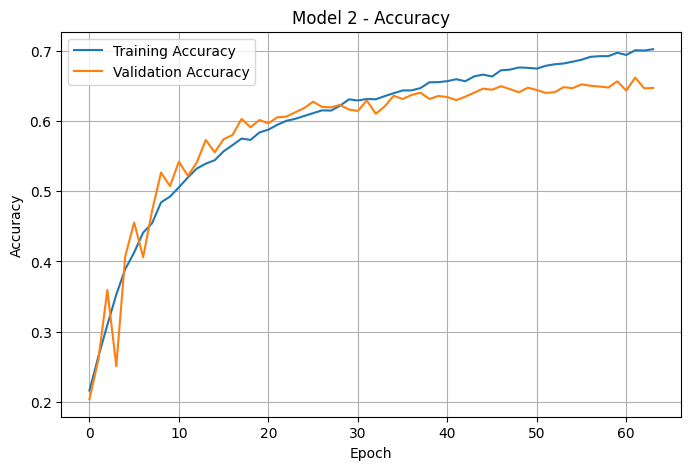

In [ ]:
# ============================================================
# Step 13: Accuracy Graph - Best Model
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(best_history.history["accuracy"], label="Training Accuracy")
plt.plot(best_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("{} - Accuracy".format(best_model_name))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

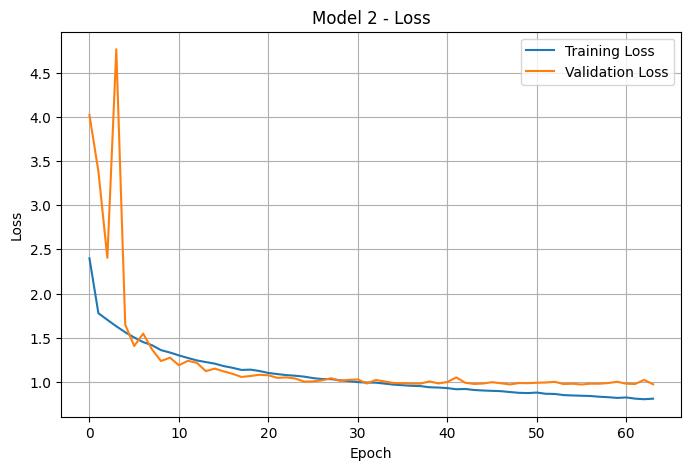

In [ ]:
# ============================================================
# Step 14: Loss Graph - Best Model
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(best_history.history["loss"], label="Training Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")

plt.title("{} - Loss".format(best_model_name))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Step 16: Emotion Labels
# ============================================================

emotion = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

print("Emotion labels:")
print(emotion)

Emotion labels:
['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


In [ ]:


# ============================================================
# Step 17: Classification Report
# ============================================================

# Get predictions from the best model
raw_prediction = best_model.predict(X_test)

# Convert one-hot encoded y_test to class labels
actual = np.argmax(y_test, axis=1)

# Convert one-hot encoded predictions to class labels
prediction = np.argmax(raw_prediction, axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        actual,
        prediction,
        target_names=emotion
    )
)


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       0.57      0.60      0.59       991
     Disgust       0.70      0.51      0.59       109
        Fear       0.55      0.40      0.46      1024
       Happy       0.90      0.84      0.87      1798
         Sad       0.54      0.61      0.57      1216
    Surprise       0.69      0.82      0.75       800
     Neutral       0.62      0.65      0.63      1240

    accuracy                           0.66      7178
   macro avg       0.65      0.63      0.64      7178
weighted avg       0.67      0.66      0.66      7178



In [ ]:
# ============================================================
# Step 18: Confusion Matrix
# ============================================================

cm = confusion_matrix(
    actual,
    prediction
)

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

print(cm)


CONFUSION MATRIX
[[ 599   11   59   27  149   39  107]
 [  30   56    5    0   12    2    4]
 [ 152    6  406   23  212  132   93]
 [  65    2   22 1516   47   52   94]
 [ 118    3  122   32  740   23  178]
 [  29    0   73   24   11  655    8]
 [  60    2   56   70  209   43  800]]


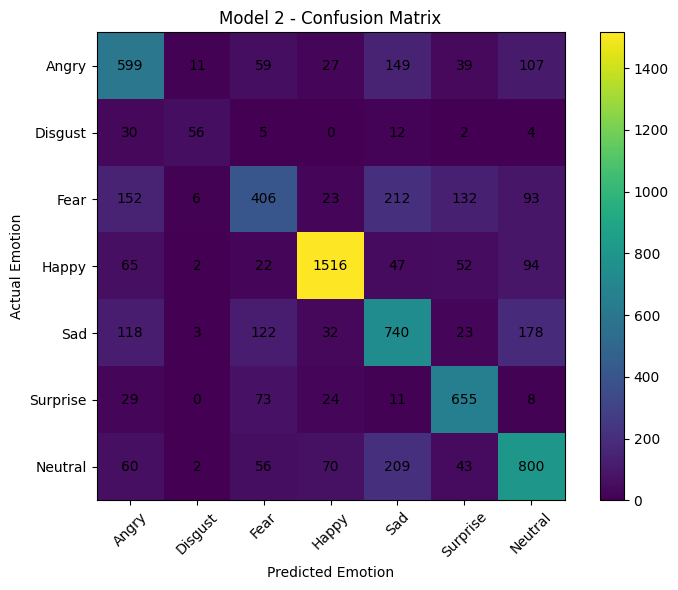

In [ ]:
# ============================================================
# Step 19: Plot Confusion Matrix
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("{} - Confusion Matrix".format(best_model_name))

plt.colorbar()

plt.xticks(
    np.arange(7),
    emotion,
    rotation=45
)

plt.yticks(
    np.arange(7),
    emotion
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

for i in range(7):
    for j in range(7):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Step 20: Save Best Model
# ============================================================

best_model.save(
    "/content/drive/MyDrive/AI_fer/best_cnn_fer_model.keras"
)

print("\n" + "="*60)
print("BEST MODEL SAVED SUCCESSFULLY")
print("="*60)

print("File:")
print("/content/drive/MyDrive/AI_fer/best_cnn_fer_model.keras")


BEST MODEL SAVED SUCCESSFULLY
File:
/content/drive/MyDrive/AI_fer/best_cnn_fer_model.keras
